<a href="https://colab.research.google.com/github/jimenami/master_ciencia_datos/blob/main/DATA_MINING/DM2025_Regresion_y_Escalabilidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Bloque de ejercicios 2 (Regresión y escalabilidad):**

En esta sesión veremos diferentes aspectos relacionados con los árboles de decisión y los algoritmos de ML en general.

Más en detalle, En esta sesión vamos a entrenar y analizar los resultados de algoritmos de regresión. Durante los ejercicios, veremos y analizaremos aspectos como el overfitting, la escalabilidad de los algoritmos y como les afecta en términos temporales. En el último ejercicio, entrenaremos un árbol de decisión teniendo en cuenta los aspectos aprendidos durante los ejercicios de la sesión.

Por último, tambien deberas responder unas preguntas relacionadas con la comprensión del temario y los resultados obtenidos.






In [1]:
import io
import pandas as pd
from google.colab import files
import numpy as np

**Overfitting**

Para comprobar el efecto del overffiting vamos a construir un conjunto de árboles sobre el mismo conjunto de datos, para ver como afecta esta característica a los resultados. Para ello, en primer lugar vamos a crear un dataset sintético con la función make_regression (https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_regression.html), con los siguientes parámetros:

*   n_samples = 10000
*   n_features = 20
*   n_informative = 5
*   random_state = 1

Comprueba las dimensiones de los conjuntos X e Y.

Visualiza tambien el conjunto de datos.





n_informative:
int, default=10
The number of informative features, i.e., the number of features used to build the linear model used to generate the output.

In [2]:
import sklearn
X, y = sklearn.datasets.make_regression(n_samples=10000, n_features=20,
                                 n_informative=5,
                                 random_state=1)
print(X.shape)
print(y.shape)

(10000, 20)
(10000,)


In [3]:
print("Conjunto X:")
X

Conjunto X:


array([[ 0.61344347,  0.92820387, -1.05573066, ..., -0.73762767,
        -0.78311531, -0.06154601],
       [-0.5213532 , -1.01546729, -0.3451861 , ...,  1.63254712,
        -0.70361346, -0.48938735],
       [-1.21132079, -1.74636342,  0.40639608, ..., -1.4722941 ,
         1.21878807, -0.6732757 ],
       ...,
       [-1.24003744, -0.06618928, -1.29921268, ...,  0.2418054 ,
        -0.11089519,  0.23216589],
       [ 0.15001628, -2.79099641, -0.45611756, ...,  0.41026575,
        -0.89868319, -1.04906775],
       [ 0.70535726,  0.65470022, -2.00619137, ..., -0.61410923,
         0.04855821,  1.47517473]])

In [4]:
print("regresor y:")
y

regresor y:


array([ 142.35032145, -256.48445751,  321.10662781, ...,  -61.31678859,
       -137.67233153, -149.56656935])

Una vez tenemos el conjunto de datos que vamos a utilizar, un split, donde utilicemos el 70% de los datos para el train y el 30% de los datos para el test. Para ello utiliza la función train_test_split de Sklearn.(https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html).

Deja la semilla del train test split a la definida por defecto (random_state=None).

Comprueba que los conjuntos x_train, x_test, y_train e y_test tienen las dimensiones adecuadas.

NOTA: Recuerda que, en entornos reales, sería necesario realizar cross validation, pero dado que queremos centrarnos en ver el efecto del overfitting y para simplificar el ejercicio, vamos a centrarnos en una única partición.






In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state=None)

print("Shape conjuntos X:")
print(X_train.shape)
print(X_test.shape)

print("Shape conjuntos y:")
print(y_train.shape)
print(y_test.shape)


Shape conjuntos X:
(7000, 20)
(3000, 20)
Shape conjuntos y:
(7000,)
(3000,)


Una vez tenemos dividido el conjunto de datos, vamos a entrenar el algoritmo DecisionTreeRegressor con diferentes parámetros para ver cual es su efecto.

Para ello, el único parámetro del algoritmo que vamos a modificar, será el parámetro (max_depth). Dicho parámetro obtendra de manera secuencial los valores en el rango [1,20]. Es decir, entrenaremos el algoritmo con un nivel de profundidad = 1, (y lo evaluaremos mediante r2), despues volveremos a entrenar para el mismo conjunto de datos, el algoritmo con el parametro max_depth=2 o 2 niveles de profundidad, etc.

Para cada iteración obten (y almacena) la medida r2 tanto para el conjunto de train como el de test.

Imprime por pantalla para cada iteración: Nº de iteracion(profundidad del arbol), r2 para el conjunto de train y r2 para el conjunto de test. Por ejemplo:

Iteración 1: Train: 0.267, Test: 0.282

Iteración 2: Train: X.XXX, Test: X.XXX

TIP: Haz un bucle para el rango especificado, que para cada iteración entrene el algoritmo, modificando el parametro max_depth. Una vez entrenado un algoritmo en una iteración, calcula el valor de r2 para el train, el test y almacena ambos resultados.

Recuerda tambien imprimirlo por pantalla como pide el ejercicio. Por último, una vez tengas entrenado todos los algoritmos.



In [6]:
coefs_train = []
coefs_test = []

for m in range(1,20):
  tree = sklearn.tree.DecisionTreeRegressor(max_depth=m)
  tree.fit(X_train, y_train)
  r2_train = tree.score(X_train, y_train)
  coefs_train.append(r2_train)
  r2_test = tree.score(X_test, y_test)
  coefs_test.append(r2_test)
  print("Iteración", m, ": Train:", r2_train, ", Test:", r2_test)

Iteración 1 : Train: 0.2700131785952741 , Test: 0.2736642083100994
Iteración 2 : Train: 0.42560268280732627 , Test: 0.4341203487294464
Iteración 3 : Train: 0.544681646849241 , Test: 0.5267230800692135
Iteración 4 : Train: 0.6488871205993714 , Test: 0.6338630387228277
Iteración 5 : Train: 0.7212894645575492 , Test: 0.6849322395678441
Iteración 6 : Train: 0.7857649640492296 , Test: 0.7401014396320336
Iteración 7 : Train: 0.8446604978507899 , Test: 0.7847227725851158
Iteración 8 : Train: 0.8925175074644778 , Test: 0.8121872295448562
Iteración 9 : Train: 0.9313262557748052 , Test: 0.8367580196764257
Iteración 10 : Train: 0.9589482668527849 , Test: 0.8406145861690041
Iteración 11 : Train: 0.9779436410889547 , Test: 0.8371060022960453
Iteración 12 : Train: 0.9894093037338524 , Test: 0.835854008597557
Iteración 13 : Train: 0.9955171904986644 , Test: 0.8336253741842591
Iteración 14 : Train: 0.9983160160063138 , Test: 0.8276814441133716
Iteración 15 : Train: 0.9994037883104407 , Test: 0.8315731

¿Que observas en los valores impresos por pantalla?

Dibuja una gráfica con los valores obtenidos de r2 de train y test para cada uno de los niveles de profundidad del árbol. Dibuja en el eje X el nivel de profundidad y en el eje Y el valor obtenido de r2 para cada conjunto.


Conforme avanza el valor del parámetro de profundidad va aumentando asimismo el valor del coeficiente de determinación r2.
No obstante, el r2 en test va aumentando hasta llegar al máximo, que es 0.84 y luego empieza a disminuir. Esto es debido al overfitting.
Vamos a dibujar la evolución de los valores en una gráfica.

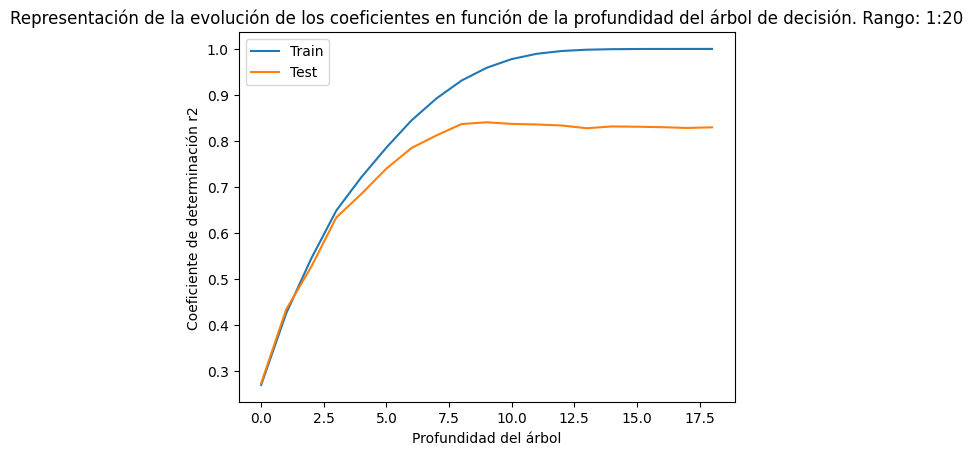

In [7]:
import matplotlib.pyplot as plt
plt.plot(coefs_train, label="Train")
plt.plot(coefs_test, label="Test")
plt.legend()
plt.xlabel("Profundidad del árbol")
plt.ylabel("Coeficiente de determinación r2")
plt.title("Representación de la evolución de los coeficientes en función de la profundidad del árbol de decisión. Rango: 1:20")
plt.show()

**Escalabilidad**

En esta segunda parte de la práctica vamos a estudiar la escalabilidad de los árboles de decisión en comparación con otros algoritmos. Los algoritmos que utilizaremos seran los siguientes:

* [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html?highlight=decisiontreeregressor#sklearn.tree.DecisionTreeRegressor)
* [KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html?highlight=kneighborsregressor#sklearn.neighbors.KNeighborsRegressor)
* [SVR con kernel RBF](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html?highlight=svr#sklearn.svm.SVR)
* [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html?highlight=linear%20regression#sklearn.linear_model.LinearRegression)

Vamos a explorar que ocurre con los siguientes aspectos de escalabilidad:

1.   Cuando crece el número de características
2.   Cuando crece el número de instancias
3.   Cuando crecen ambas dimensiones


**1.   Cuando crece el número de características**

Para este ejercicio, vamos a hacer uso de la función make_regression. En este caso, crearemos un bucle donde para cada iteración se cree un conjunto de datos donde se modifique para cada iteración el número de columnas  en el rango [10,100]. Aumenta el contador en 10 para cada iteración.


Para cada iteración realizaremos los siguientes pasos:

1.   Crearemos el conjunto de datos con los parametros (*n_samples=5000, n_features = i, n_informative=10, random_state=1*).
2.   Una vez creado el conjunto de datos, definimos los *decisionTreeRegressor, KNeighborsRegressor, SVR y LinearRegression*.
3.   Obtenemos el tiempo antes y despues del fit de cada uno de los modelos (y lo almacenamos)
4. Imprime por pantalla el Nº de características para esa iteración y los tiempos de entrenamiento para cada uno de los modelos.









In [14]:

import datetime
Tiempo1 = []
Tiempo2 = []
Tiempo3 = []
Tiempo4 = []

for i in range(1,11):
  X, y = sklearn.datasets.make_regression(n_samples=5000, n_features =i*10, n_informative=10, random_state=1)
  tree = sklearn.tree.DecisionTreeRegressor()
  knn = sklearn.neighbors.KNeighborsRegressor()
  svr = sklearn.svm.SVR()
  lr = sklearn.linear_model.LinearRegression()
  # Obtenemos el tiempo antes del fit de cada modelo y después de cada modelo
  date = datetime.datetime.now()
  tree.fit(X,y)
  date1 = datetime.datetime.now()
  knn.fit(X,y)
  date2 = datetime.datetime.now()
  svr.fit(X,y)
  date3 = datetime.datetime.now()
  lr.fit(X,y)
  date4 = datetime.datetime.now()
  # Restamos la diferencia entre el antes y el después para cada modelo
  tiempo1 = date1-date
  Tiempo1.append(tiempo1)
  tiempo2 = date2-date1
  Tiempo2.append(tiempo2)
  tiempo3 = date3-date2
  Tiempo3.append(tiempo3)
  tiempo4 = date4-date3
  Tiempo4.append(tiempo4)
  print("Iteración:", i, "n_features:", i*10)
  print("Árbol de regresión:", tiempo1)
  print("KNN:", tiempo2)
  print("SVR:", tiempo3)
  print("Regresión lineal", tiempo4)

Iteración: 1 n_features: 10
Árbol de regresión: 0:00:00.104595
KNN: 0:00:00.006659
SVR: 0:00:01.280236
Regresión lineal 0:00:00.002644
Iteración: 2 n_features: 20
Árbol de regresión: 0:00:00.229133
KNN: 0:00:00.000793
SVR: 0:00:01.297522
Regresión lineal 0:00:00.003650
Iteración: 3 n_features: 30
Árbol de regresión: 0:00:00.333952
KNN: 0:00:00.000855
SVR: 0:00:01.627449
Regresión lineal 0:00:00.008478
Iteración: 4 n_features: 40
Árbol de regresión: 0:00:00.556592
KNN: 0:00:00.001125
SVR: 0:00:02.620253
Regresión lineal 0:00:00.007511
Iteración: 5 n_features: 50
Árbol de regresión: 0:00:00.523107
KNN: 0:00:00.000946
SVR: 0:00:01.467392
Regresión lineal 0:00:00.012798
Iteración: 6 n_features: 60
Árbol de regresión: 0:00:00.610665
KNN: 0:00:00.001109
SVR: 0:00:01.983566
Regresión lineal 0:00:00.015744
Iteración: 7 n_features: 70
Árbol de regresión: 0:00:00.706055
KNN: 0:00:00.001040
SVR: 0:00:01.868581
Regresión lineal 0:00:00.019980
Iteración: 8 n_features: 80
Árbol de regresión: 0:00:00

Dibuja en una gráfica el tiempo de entrenamiento para cada uno de los algoritmos. ¿Qué conclusiones obtienes?

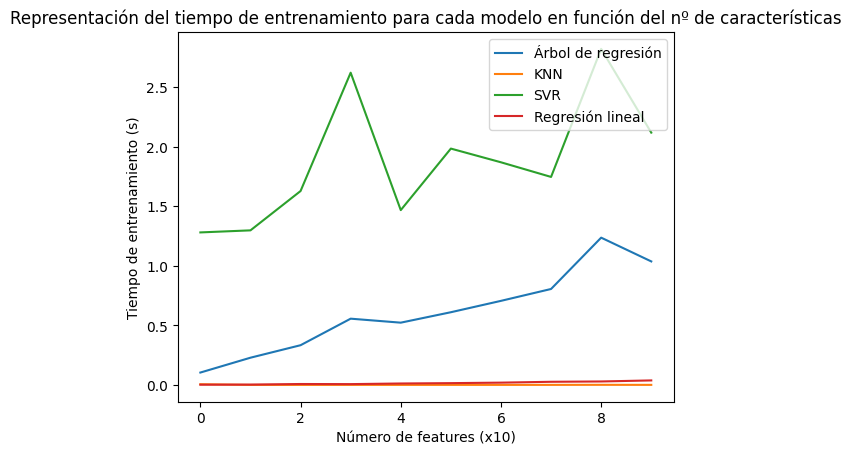

In [16]:
# Tenemos que hacer una transformación a segundos de los valores de las listas de Tiempo para poder graficarlos:
Tiempo1 = [t.total_seconds() for t in Tiempo1]
Tiempo2 = [t.total_seconds() for t in Tiempo2]
Tiempo3 = [t.total_seconds() for t in Tiempo3]
Tiempo4 = [t.total_seconds() for t in Tiempo4]

plt.plot(Tiempo1, label="Árbol de regresión")
plt.plot(Tiempo2, label="KNN")
plt.plot(Tiempo3, label="SVR")
plt.plot(Tiempo4, label="Regresión lineal")
plt.legend()
plt.xlabel("Número de features (x10)")
plt.ylabel("Tiempo de entrenamiento (s)")
plt.title("Representación del tiempo de entrenamiento para cada modelo en función del nº de características")
plt.show()


**2.   Cuando crece el número de instancias**

Para este ejercicio modificaremos el número de muestras en el dataset. Es decir, para cada iteración crearemos un dataset (haciendo uso de la funcion make_regression) modificando el parametro n_samples en el rango [1.000,10.000].

Para cada iteración realizaremos los siguientes pasos:

1.   Crearemos el conjunto de datos con los parametros (*n_samples=i, n_features = 100, n_informative=10, random_state=1*).
2.   Una vez creado el conjunto de datos, definimos los *decisionTreeRegressor, KNeighborsRegressor, SVR y LinearRegression*.
3.   Obtenemos el tiempo antes y despues del fit de cada uno de los modelos (y lo almacenamos)
4. Imprime por pantalla el Nº de muestras para esa iteración y los tiempos de entrenamiento para cada uno de los modelos.

In [18]:
Tiempo1 = []
Tiempo2 = []
Tiempo3 = []
Tiempo4 = []
#Vamos a ir de 100 en 100 porque si no es demasiado
for i in range(10,101):
  X, y = sklearn.datasets.make_regression(n_samples=i*100, n_features =100, n_informative=10, random_state=1)
  tree = sklearn.tree.DecisionTreeRegressor()
  knn = sklearn.neighbors.KNeighborsRegressor()
  svr = sklearn.svm.SVR()
  lr = sklearn.linear_model.LinearRegression()
  # Obtenemos el tiempo antes del fit de cada modelo y después de cada modelo
  date = datetime.datetime.now()
  tree.fit(X,y)
  date1 = datetime.datetime.now()
  knn.fit(X,y)
  date2 = datetime.datetime.now()
  svr.fit(X,y)
  date3 = datetime.datetime.now()
  lr.fit(X,y)
  date4 = datetime.datetime.now()
  # Restamos la diferencia entre el antes y el después para cada modelo
  tiempo1 = date1-date
  Tiempo1.append(tiempo1)
  tiempo2 = date2-date1
  Tiempo2.append(tiempo2)
  tiempo3 = date3-date2
  Tiempo3.append(tiempo3)
  tiempo4 = date4-date3
  Tiempo4.append(tiempo4)
  print("Iteración:", i%100, "n_features:", i*100)
  print("Árbol de regresión:", tiempo1)
  print("KNN:", tiempo2)
  print("SVR:", tiempo3)
  print("Regresión lineal", tiempo4)

Iteración: 0 n_features: 1000
Árbol de regresión: 0:00:00.149713
KNN: 0:00:00.000837
SVR: 0:00:00.076621
Regresión lineal 0:00:00.009656
Iteración: 1 n_features: 1100
Árbol de regresión: 0:00:00.196226
KNN: 0:00:00.001372
SVR: 0:00:00.094181
Regresión lineal 0:00:00.009954
Iteración: 2 n_features: 1200
Árbol de regresión: 0:00:00.242551
KNN: 0:00:00.000836
SVR: 0:00:00.111972
Regresión lineal 0:00:00.010715
Iteración: 3 n_features: 1300
Árbol de regresión: 0:00:00.235383
KNN: 0:00:00.001028
SVR: 0:00:00.133375
Regresión lineal 0:00:00.012312
Iteración: 4 n_features: 1400
Árbol de regresión: 0:00:00.244805
KNN: 0:00:00.000835
SVR: 0:00:00.181313
Regresión lineal 0:00:00.011486
Iteración: 5 n_features: 1500
Árbol de regresión: 0:00:00.263797
KNN: 0:00:00.000862
SVR: 0:00:00.189839
Regresión lineal 0:00:00.011823
Iteración: 6 n_features: 1600
Árbol de regresión: 0:00:00.289513
KNN: 0:00:00.000892
SVR: 0:00:00.229856
Regresión lineal 0:00:00.017182
Iteración: 7 n_features: 1700
Árbol de re

Dibuja en una gráfica el tiempo de entrenamiento para cada uno de los algoritmos. ¿Qué conclusiones obtienes?

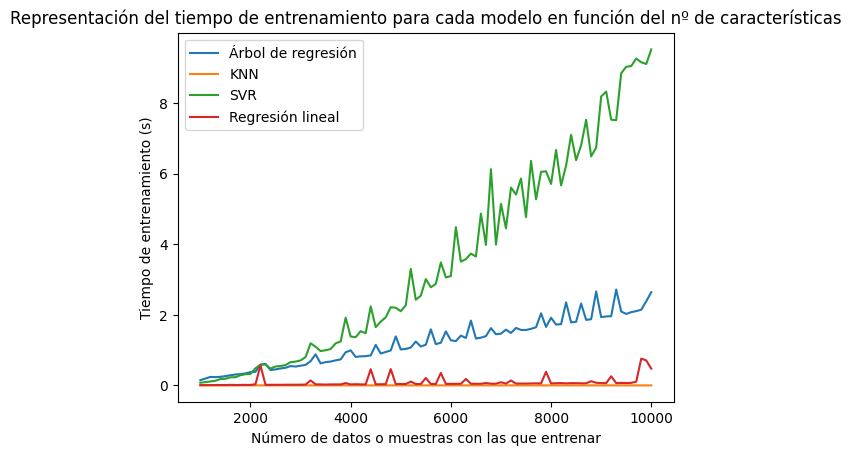

In [21]:
# Tenemos que hacer una transformación a segundos de los valores de las listas de Tiempo para poder graficarlos:
Tiempo1 = [t.total_seconds() for t in Tiempo1]
Tiempo2 = [t.total_seconds() for t in Tiempo2]
Tiempo3 = [t.total_seconds() for t in Tiempo3]
Tiempo4 = [t.total_seconds() for t in Tiempo4]

# Vamos a hacer una transformación al eje de las x
x = [i*100 for i in range(10,101)]
plt.plot(x,Tiempo1, label="Árbol de regresión")
plt.plot(x,Tiempo2, label="KNN")
plt.plot(x,Tiempo3, label="SVR")
plt.plot(x,Tiempo4, label="Regresión lineal")
plt.legend()
plt.xlabel("Número de datos o muestras con las que entrenar")
plt.ylabel("Tiempo de entrenamiento (s)")
plt.title("Representación del tiempo de entrenamiento para cada modelo en función del nº de características")
plt.show()

Los picos en la gráfica aparecen proque hemos calculado los registros de tiempo de 100 en 100.
Al igual que en el caso anterior, el mejor modelo en cuanto a velocidad es el de los vecinos más cercanos y el pero el SVM.

**3.   Cuando crecen ambas dimensiones (número de muestras y número de características)**

Para este ejercicio, vamos a probar que ocurre si aumentamos el tamaño del dataset en función del número de muestras y el número de características.

Para ello, crea dos listas con los valores del número de muestras y el número de características que usaremos en la función make_regression. El número de muestras estara en el rango [1.000, 10.000] aumentando de 1.000 en 1.000. Para el número de características vamos a probar sobre 10 conjuntos de datos. Crea dos listas (una para el número de características aumentara de 10 en 10 en el rango [10,100].

Para cada iteración de las 10 iteraciones realizaremos los siguientes pasos:

1.   Crearemos el conjunto de datos con los parametros (*n_samples=samples[i], n_features = features[i], n_informative=10, random_state=1*).
2.   Una vez creado el conjunto de datos, definimos los *decisionTreeRegressor, KNeighborsRegressor, SVR y LinearRegression*.
3.   Obtenemos el tiempo antes y despues del fit de cada uno de los modelos (y lo almacenamos)
4. Imprime por pantalla el Nº de muestras para esa iteración y los tiempos de entrenamiento para cada uno de los modelos.

In [24]:
samples = []
features = []
for i in range(1000,11000,1000):
  samples.append(i)

for j in range(10,110,10):
  features.append(j)

print(samples)
print(features)

[1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
[10, 20, 30, 40, 50, 60, 70, 80, 90, 100]


In [25]:
Tiempo1 = []
Tiempo2 = []
Tiempo3 = []
Tiempo4 = []
#Vamos a ir de 100 en 100 porque si no es demasiado
for i in range(10):
  X, y = sklearn.datasets.make_regression(n_samples=samples[i], n_features =features[i], n_informative=10, random_state=1)
  tree = sklearn.tree.DecisionTreeRegressor()
  knn = sklearn.neighbors.KNeighborsRegressor()
  svr = sklearn.svm.SVR()
  lr = sklearn.linear_model.LinearRegression()
  # Obtenemos el tiempo antes del fit de cada modelo y después de cada modelo
  date = datetime.datetime.now()
  tree.fit(X,y)
  date1 = datetime.datetime.now()
  knn.fit(X,y)
  date2 = datetime.datetime.now()
  svr.fit(X,y)
  date3 = datetime.datetime.now()
  lr.fit(X,y)
  date4 = datetime.datetime.now()
  # Restamos la diferencia entre el antes y el después para cada modelo
  tiempo1 = date1-date
  Tiempo1.append(tiempo1)
  tiempo2 = date2-date1
  Tiempo2.append(tiempo2)
  tiempo3 = date3-date2
  Tiempo3.append(tiempo3)
  tiempo4 = date4-date3
  Tiempo4.append(tiempo4)
  print("Iteración:", i, "n_features:", features[i], "n_samples:", samples[i])
  print("Árbol de regresión:", tiempo1)
  print("KNN:", tiempo2)
  print("SVR:", tiempo3)
  print("Regresión lineal", tiempo4)

Iteración: 0 n_features: 10 n_samples: 1000
Árbol de regresión: 0:00:00.017046
KNN: 0:00:00.002093
SVR: 0:00:00.053191
Regresión lineal 0:00:00.001745
Iteración: 1 n_features: 20 n_samples: 2000
Árbol de regresión: 0:00:00.096756
KNN: 0:00:00.000902
SVR: 0:00:00.222729
Regresión lineal 0:00:00.002322
Iteración: 2 n_features: 30 n_samples: 3000
Árbol de regresión: 0:00:00.202504
KNN: 0:00:00.000979
SVR: 0:00:00.561148
Regresión lineal 0:00:00.003742
Iteración: 3 n_features: 40 n_samples: 4000
Árbol de regresión: 0:00:00.327509
KNN: 0:00:00.000885
SVR: 0:00:01.004047
Regresión lineal 0:00:00.006346
Iteración: 4 n_features: 50 n_samples: 5000
Árbol de regresión: 0:00:00.540572
KNN: 0:00:00.000956
SVR: 0:00:01.497020
Regresión lineal 0:00:00.011542
Iteración: 5 n_features: 60 n_samples: 6000
Árbol de regresión: 0:00:00.750739
KNN: 0:00:00.001104
SVR: 0:00:02.975046
Regresión lineal 0:00:00.018512
Iteración: 6 n_features: 70 n_samples: 7000
Árbol de regresión: 0:00:01.383388
KNN: 0:00:00.00

Dibuja en una gráfica el tiempo de entrenamiento para cada uno de los algoritmos. ¿Qué conclusiones obtienes?

In [26]:
# Tenemos que hacer una transformación a segundos de los valores de las listas de Tiempo para poder graficarlos:
Tiempo1 = [t.total_seconds() for t in Tiempo1]
Tiempo2 = [t.total_seconds() for t in Tiempo2]
Tiempo3 = [t.total_seconds() for t in Tiempo3]
Tiempo4 = [t.total_seconds() for t in Tiempo4]

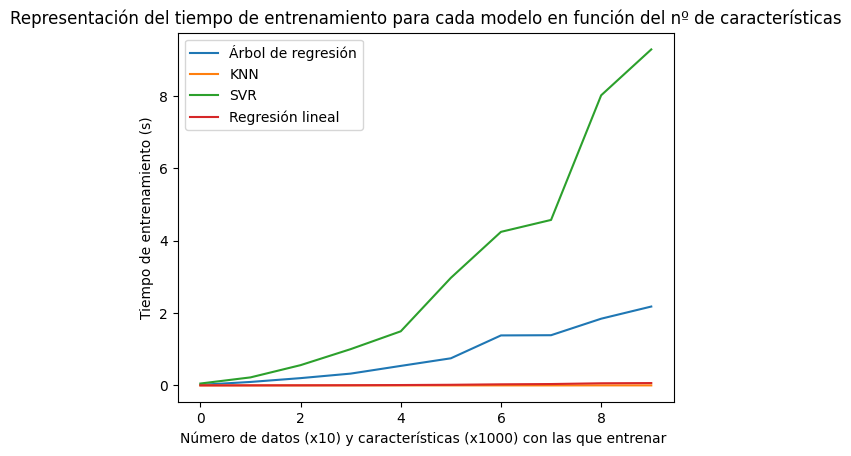

In [28]:

# Vamos a hacer una transformación al eje de las x
plt.plot(Tiempo1, label="Árbol de regresión")
plt.plot(Tiempo2, label="KNN")
plt.plot(Tiempo3, label="SVR")
plt.plot(Tiempo4, label="Regresión lineal")
plt.legend()
plt.xlabel("Número de datos (x10) y características (x1000) con las que entrenar ")
plt.ylabel("Tiempo de entrenamiento (s)")
plt.title("Representación del tiempo de entrenamiento para cada modelo en función del nº de características")
plt.show()

Contruye un decisionTree Regressor para el dataset "California_housing_train.csv" del repositorio de ejemplo (df = pd.read_csv('sample_data/california_housing_train.csv', sep=','))

La etiqueta a predecir es 'median_house_value. Empieza cargando el conjunto de datos, y separando las etiquetas de los datos.

In [76]:
California = pd.read_csv('sample_data/california_housing_train.csv', sep=',')
y = California['median_house_value']
X = California.drop('median_house_value', axis=1)
print(X.head())
X.shape

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  
0      1015.0       472.0         1.4936  
1      1129.0       463.0         1.8200  
2       333.0       117.0         1.6509  
3       515.0       226.0         3.1917  
4       624.0       262.0         1.9250  


(17000, 8)

Entrena el decisionTreeRegressor con diferentes parámetros de max_depth para encontrar el punto de overfitting (de manera similar al ejercicio de overfitting realizado anteriormente).

Dibuja las gráficas para r2, mae y mse.

¿Qué parametro elegirías de max_depth para evitar el overffiting?


In [77]:
# Dividimos los datos en conjuntos de train y test 70-30%
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.3, random_state=1)

In [81]:
R2_train = []
R2_test = []
Mae_train = []
Mae_test = []
Mse_train = []
Mse_test = []

# Ahora el parámetro para la profundidad va a estar en el rango (1,8)
for i in range(1,9):
  tree = sklearn.tree.DecisionTreeRegressor(max_depth=i)
  tree.fit(X_train,y_train)
  r2 = tree.score(X_train,y_train)
  mae = sklearn.metrics.mean_absolute_error(y_train, tree.predict(X_train))
  mse = sklearn.metrics.mean_squared_error(y_train, tree.predict(X_train))
  R2_train.append(r2)
  Mae_train.append(mae)
  Mse_train.append(mse)
  r2_test = tree.score(X_test,y_test)
  mae_test = sklearn.metrics.mean_absolute_error(y_test, tree.predict(X_test))
  mse_test = sklearn.metrics.mean_squared_error(y_test, tree.predict(X_test))
  R2_test.append(r2_test)
  Mae_test.append(mae_test)
  Mse_test.append(mse_test)
  print("Métricas para el conjunto de train:")
  print("Profundidad:", i, "r2:", r2, "mae:", mae, "mse:", mse)
  print("Métricas para el conjunto de test:")
  print("Profundidad:", i, "r2:", r2_test, "mae:", mae_test, "mse:", mse_test)
  print("\n")


Métricas para el conjunto de train:
Profundidad: 1 r2: 0.319399079594724 mae: 74592.70543456191 mse: 9198817518.906912
Métricas para el conjunto de test:
Profundidad: 1 r2: 0.3004515878747107 mae: 75109.06076574067 mse: 9304382833.721054


Métricas para el conjunto de train:
Profundidad: 2 r2: 0.4516966787808575 mae: 65667.19977589673 mse: 7410719036.20422
Métricas para el conjunto de test:
Profundidad: 2 r2: 0.4519343494354582 mae: 65365.640251400146 mse: 7289577879.781649


Métricas para el conjunto de train:
Profundidad: 3 r2: 0.49870197536037797 mae: 61278.69011486494 mse: 6775408191.488301
Métricas para el conjunto de test:
Profundidad: 3 r2: 0.49868886269588175 mae: 60978.32180298985 mse: 6667716857.672208


Métricas para el conjunto de train:
Profundidad: 4 r2: 0.5644474802235313 mae: 56477.143175317884 mse: 5886809772.367112
Métricas para el conjunto de test:
Profundidad: 4 r2: 0.5698276455279734 mae: 55830.291150506804 mse: 5721531492.482389


Métricas para el conjunto de trai

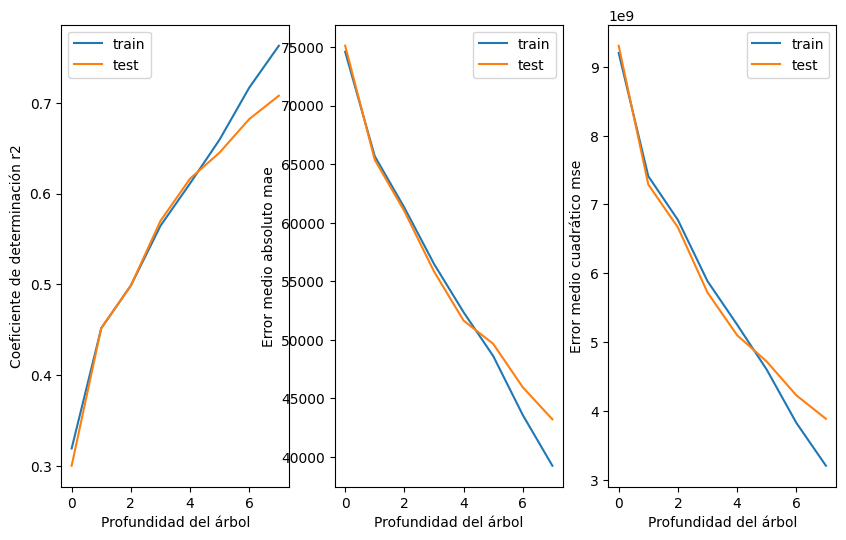

In [82]:
# Tengo que poner las variables en distintas gráficas
plt.figure(figsize=(10,6))
plt.subplot(1,3,1)
plt.plot(R2_train, label="train")
plt.plot(R2_test, label = "test")
plt.legend()
plt.xlabel("Profundidad del árbol")
plt.ylabel("Coeficiente de determinación r2")
plt.subplot(1,3,2)
plt.plot(Mae_train, label = "train")
plt.plot(Mae_test, label = "test")
plt.legend()
plt.xlabel("Profundidad del árbol")
plt.ylabel("Error medio absoluto mae")
plt.subplot(1,3,3)
plt.plot(Mse_train, label = "train")
plt.plot(Mse_test, label = "test")
plt.legend()
plt.xlabel("Profundidad del árbol")
plt.ylabel("Error medio cuadrático mse")
plt.show()

El codo parece darse en las 3 gráficas en las mismas iteraciones: la iteración 4, que es cuando empieza a cambiar la pendiente de la línea.
Es por esto que yo elegiría darle máxima profundidad al árbol = 4 como máximo porque si ponemos más se estaría dando el fenómeno de overfitting, ya que disminuye en exceso el error de test.

Has identificado el punto de overfitting en función del parámetro max_depths, pero que ocurre con el resto de parámetros del arbol?

Parámetro min_samples_split




In [83]:
# Vamos a hacer lo mismo pero variando ahora el rango de este parámetro
# Como tenemos 17000 muestras, vamos a probar un rango que vaya de 2 a 500 de 10 en 10
# El parámetro min_samples_split define el nº mínimo de muestras que debe tener un nodo para poder dividirse

R2_train = []
R2_test = []
Mae_train = []
Mae_test = []
Mse_train = []
Mse_test = []

# Ahora el parámetro para la profundidad va a estar en el rango (2,500)
for i in range(2,501, 10):
  tree = sklearn.tree.DecisionTreeRegressor(min_samples_split=i)
  tree.fit(X_train,y_train)
  r2 = tree.score(X_train,y_train)
  mae = sklearn.metrics.mean_absolute_error(y_train, tree.predict(X_train))
  mse = sklearn.metrics.mean_squared_error(y_train, tree.predict(X_train))
  R2_train.append(r2)
  Mae_train.append(mae)
  Mse_train.append(mse)
  r2_test = tree.score(X_test,y_test)
  mae_test = sklearn.metrics.mean_absolute_error(y_test, tree.predict(X_test))
  mse_test = sklearn.metrics.mean_squared_error(y_test, tree.predict(X_test))
  R2_test.append(r2_test)
  Mae_test.append(mae_test)
  Mse_test.append(mse_test)


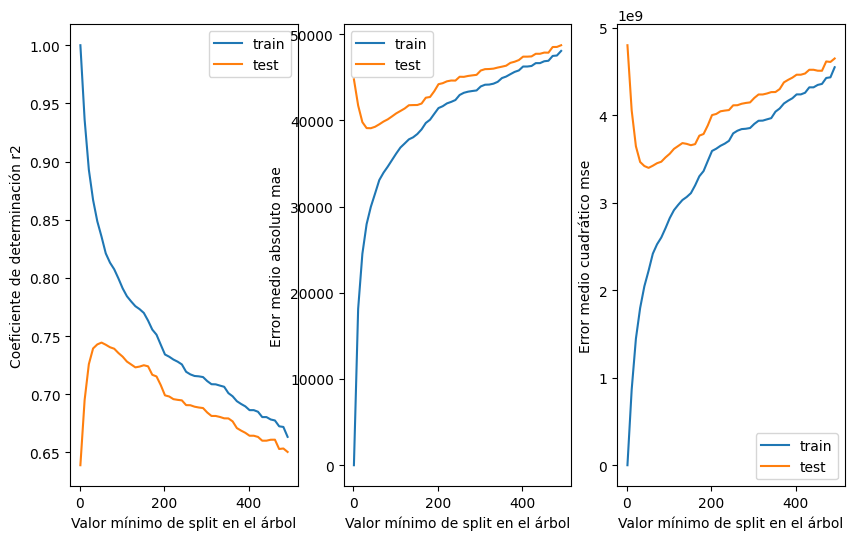

In [84]:
# Graficamos la evolución
# Tengo que poner las variables en distintas gráficas
# Vamos a reescalar el eje de las x
x = [i for i in range(2,501, 10)]
plt.figure(figsize=(10,6))
plt.subplot(1,3,1)
plt.plot(x,R2_train, label="train")
plt.plot(x,R2_test, label = "test")
plt.legend()
plt.xlabel("Valor mínimo de split en el árbol")
plt.ylabel("Coeficiente de determinación r2")
plt.subplot(1,3,2)
plt.plot(x,Mae_train, label = "train")
plt.plot(x,Mae_test, label = "test")
plt.legend()
plt.xlabel("Valor mínimo de split en el árbol")
plt.ylabel("Error medio absoluto mae")
plt.subplot(1,3,3)
plt.plot(x,Mse_train, label = "train")
plt.plot(x,Mse_test, label = "test")
plt.legend()
plt.xlabel("Valor mínimo de split en el árbol")
plt.ylabel("Error medio cuadrático mse")
plt.show()

In [85]:
# El valor más alto del r2 en test se da para el idx:
idx = np.argmax(R2_test)
print(idx)
print(R2_test[idx])


# Es decir, para min_split = 52

5
0.7444446367698283


In [86]:
# Los valores mínimos de error mae y mse en el conjunto de test se dan para:
idx = np.argmin(Mae_test)
print(idx)
print(Mae_test[idx])

idx2 = np.argmin(Mse_test)
print(idx2)
print(Mse_test[idx2])

# Es decir, para 42 y 52 muestras respectivamente

4
39081.943947103624
5
3399028421.0355635


Viendo esto sabemos que para evitar el overfitting no podemos escoger menos de 52 muestras por split en el árbol

Min_samples_leafs

In [87]:
# Ahora vamos a hacer lo mismo pero variado el siguiente parámetro que es min_samples_leafs, que es el número mínimo de hojas que debe tener el árbol
# El parámetro min_samples_leafs define el nº de muestras mínimas para las que debe ser válida cualquier decisión que tome el árbol

# Voy a considerar un rango (1,500)

R2_train = []
R2_test = []
Mae_train = []
Mae_test = []
Mse_train = []
Mse_test = []

# Ahora el parámetro para la profundidad va a estar en el rango (1,500) de 10 en 10
for i in range(1,501, 10):
  tree = sklearn.tree.DecisionTreeRegressor(min_samples_leaf=i)
  tree.fit(X_train,y_train)
  r2 = tree.score(X_train,y_train)
  mae = sklearn.metrics.mean_absolute_error(y_train, tree.predict(X_train))
  mse = sklearn.metrics.mean_squared_error(y_train, tree.predict(X_train))
  R2_train.append(r2)
  Mae_train.append(mae)
  Mse_train.append(mse)
  r2_test = tree.score(X_test,y_test)
  mae_test = sklearn.metrics.mean_absolute_error(y_test, tree.predict(X_test))
  mse_test = sklearn.metrics.mean_squared_error(y_test, tree.predict(X_test))
  R2_test.append(r2_test)
  Mae_test.append(mae_test)
  Mse_test.append(mse_test)

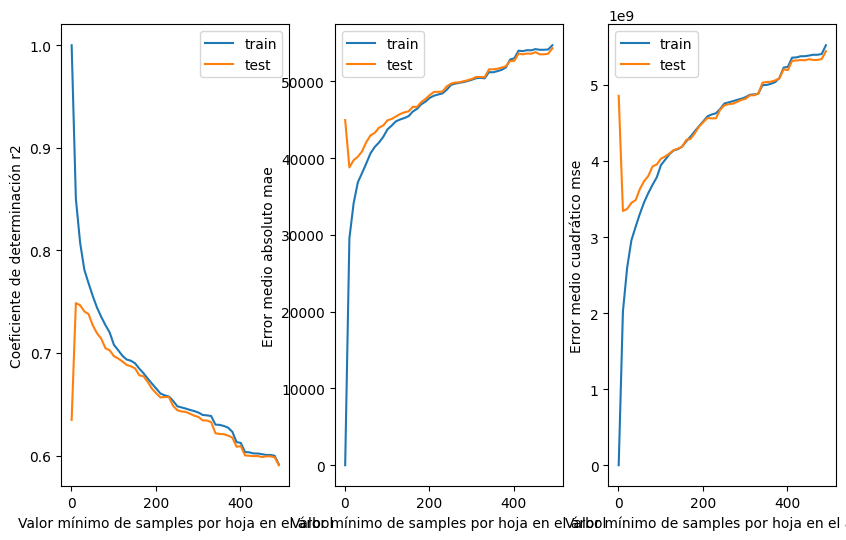

In [88]:
# Graficamos la evolución
# Tengo que poner las variables en distintas gráficas
# Vamos a reescalar el eje de las x
x = [i for i in range(1,501, 10)]
plt.figure(figsize=(10,6))
plt.subplot(1,3,1)
plt.plot(x,R2_train, label="train")
plt.plot(x,R2_test, label = "test")
plt.legend()
plt.xlabel("Valor mínimo de samples por hoja en el árbol")
plt.ylabel("Coeficiente de determinación r2")
plt.subplot(1,3,2)
plt.plot(x,Mae_train, label = "train")
plt.plot(x,Mae_test, label = "test")
plt.legend()
plt.xlabel("Valor mínimo de samples por hoja en el árbol")
plt.ylabel("Error medio absoluto mae")
plt.subplot(1,3,3)
plt.plot(x,Mse_train, label = "train")
plt.plot(x,Mse_test, label = "test")
plt.legend()
plt.xlabel("Valor mínimo de samples por hoja en el árbol")
plt.ylabel("Error medio cuadrático mse")
plt.show()

In [89]:
# Obtenemos el valor máximo del coeficiente de determinación en el conjunto de test
idx = np.argmax(R2_test)
print(idx)
print(R2_test[idx])

# Es decir, para mínimo de muestras por hoja = 10 se obtiene un coeficiente de determinación de 0.84974

1
0.7486644185238577


In [90]:
# Ahora obtenemos los valores mínimos de los errores mae y mse en el conjunto de test
idx = np.argmin(Mae_test)
print(idx)
print(Mae_test[idx])

idx2 = np.argmin(Mse_test)
print(idx2)
print(Mse_test[idx2])

# De nuevo sale mínimo 10 muestras por hoja para ambos casos

1
38804.91687147972
1
3342902977.486979


Viendo esto, sabemos que para evitar el overfitting no podríamos bajar de 10 muestras por hoja

¿Qué parámetros eligirias al final?

Los resultados obtenidos es fruto del conjunto de test aleatorio obtenido, o ¿se obtienen resultados similares para diferentes particiones? Utiliza varias medidas de evaluación como r2, mae y mse.

Habiendo visto las gráficas anteriores, elegiría:
* max_depth = 4
* min_samples_split = 52
* min_samples_leaf = 10

In [93]:
# Usando estos valores de los parámetros entrenamos y testeamos el árbol
tree_final = sklearn.tree.DecisionTreeRegressor(max_depth=4, min_samples_split=52, min_samples_leaf = 10)
tree_final.fit(X_train,y_train)
print("Métricas en el conjunto de train:")
print("r2:", tree_final.score(X_train,y_train))
print("mae:", sklearn.metrics.mean_absolute_error(y_train, tree_final.predict(X_train)))
print("mse:", sklearn.metrics.mean_squared_error(y_train, tree_final.predict(X_train)))
print("\n")
print("Métricas en el conjunto de test:")
print("r2:", tree_final.score(X_test,y_test))
print("mae:", sklearn.metrics.mean_absolute_error(y_test, tree_final.predict(X_test)))
print("mse:", sklearn.metrics.mean_squared_error(y_test, tree_final.predict(X_test)))


Métricas en el conjunto de train:
r2: 0.5641077099443925
mae: 56496.94941541531
mse: 5891402015.343045


Métricas en el conjunto de test:
r2: 0.5702078309993084
mae: 55816.52521033884
mse: 5716474814.32859


Obten la importancia de variables del modelo final obtenido

In [99]:
# Calculamos la importancia de Gini de las variables del árbol
importances = tree_final.feature_importances_
X = California.drop('median_house_value', axis=1)

# Creamos un dataframe con las variables y sus importancias:
df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importances
}).sort_values(by='Importancia', ascending=False)

print(df_importancia)

             Variable  Importancia
7       median_income     0.828456
0           longitude     0.091765
1            latitude     0.049928
2  housing_median_age     0.025648
6          households     0.004202
3         total_rooms     0.000000
5          population     0.000000
4      total_bedrooms     0.000000


La variable más importante parra el árbol a la hora de hacer los splits es la median_income, que está a muchísima diferencia en cuanto a importancia del resto de variables

Han aprendido todos los modelos de cada uno de los folds lo mismo? Obten los coeficientes para cada una de las iteraciones del kfold

In [108]:
# Vamos a realizar una validación cruzada en el conjunto entero de datos con k = 5 y a calcular la importancia de Gini para las variables en cada fold
from sklearn.model_selection import KFold

cv = KFold(n_splits=5, shuffle=True, random_state=1)
tree = sklearn.tree.DecisionTreeRegressor(max_depth = 4, min_samples_split = 52, min_samples_leaf=10)
for train_idx, test_idx in cv.split(X):
  X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
  y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
  tree.fit(X_train,y_train)
  importances = tree.feature_importances_
  df_importancia = pd.DataFrame(
      {'Variable': X.columns,
       'Importancia': importances}).sort_values(by='Importancia', ascending=False)
  print("K-Fold:" )
  print(df_importancia)
  print("\n")


K-Fold:
             Variable  Importancia
7       median_income     0.835764
0           longitude     0.068936
2  housing_median_age     0.052233
1            latitude     0.038986
6          households     0.004080
3         total_rooms     0.000000
5          population     0.000000
4      total_bedrooms     0.000000


K-Fold:
             Variable  Importancia
7       median_income     0.825999
0           longitude     0.089856
1            latitude     0.051261
2  housing_median_age     0.029571
6          households     0.003313
3         total_rooms     0.000000
5          population     0.000000
4      total_bedrooms     0.000000


K-Fold:
             Variable  Importancia
7       median_income     0.828880
0           longitude     0.064148
2  housing_median_age     0.062333
1            latitude     0.041842
6          households     0.002797
3         total_rooms     0.000000
5          population     0.000000
4      total_bedrooms     0.000000


K-Fold:
             Vari

Para todos los folds la variable más importante es median_income, seguida de longitud y latitud, en distinto orden dependiendo del fold.

¿Qué conclusiones sacas? ¿Cuáles son las 3 variables más importantes?

¿Qué ocurre con la columna household? ¿A qué se deben esos cambios?





La columna households, que mide el nº de hogares por unidad de vivienda, pasa de ser la menos importante a la segunda menos importante siendo desbancada por total_bedrooms, dependiendo del fold. Como podemos ver es una variable que cambia mucho de posición en importancia dependiendo del fold en el que nos encontremos. Esto pasa porque cada fold coge una combinación aleatoria de los datos para entrenar y para testear y el árbol es muy sensible a estas configuraciones.

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.925208           -0.114250     0.047010   
latitude            -0.925208  1.000000            0.016454    -0.038773   
housing_median_age  -0.114250  0.016454            1.000000    -0.360984   
total_rooms          0.047010 -0.038773           -0.360984     1.000000   
total_bedrooms       0.071802 -0.069373           -0.320434     0.928403   
population           0.101674 -0.111261           -0.295890     0.860170   
households           0.059628 -0.074902           -0.302754     0.919018   
median_income       -0.015485 -0.080303           -0.115932     0.195383   

                    total_bedrooms  population  households  median_income  
longitude                 0.071802    0.101674    0.059628      -0.015485  
latitude                 -0.069373   -0.111261   -0.074902      -0.080303  
housing_median_age       -0.320434   -0.295890   -0.302754      -0.115932  
total_rooms

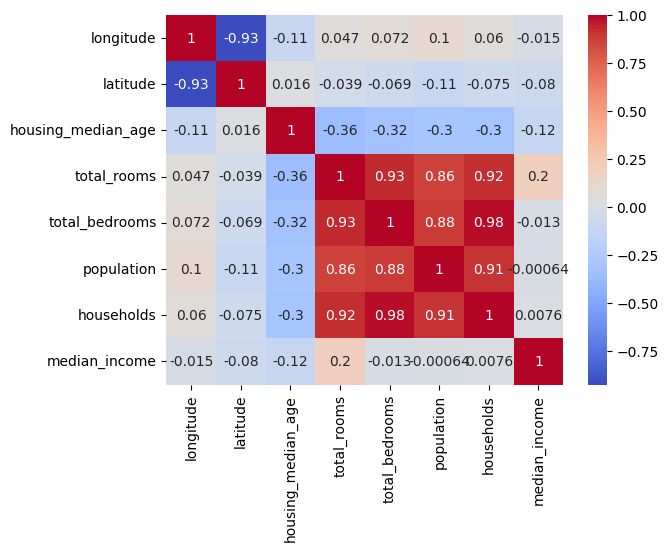

In [107]:
# Calculamos la correlación entre household y el resto de variables.
import seaborn as sns
matriz_corr = X.corr()
print(matriz_corr)

# Visualizar la matriz con un mapa de calor (heatmap)
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm')
plt.show()

Si nos fijamos, households está super correlacionada (0.92, 0.98 y 0.91) con las variables total_rooms, total_bedrooms y population.
Por tanto, si en un fold se le da más importancia a alguna de estas 4 variables,esto automáticamente "desbanca" a las demás y hace que reciban menos porque se entiende que la información de una ya está contenida de alguna forma implícita en las demás.

Por último, vuelve a entrenar el modelo, pero esta vez utiliza únicamente las tres variables más importantes obtenidas anteriormente. Compara con los resultados obtenidos anteriormente. Obten de nuevo los coeficientes de los modelos. ¿Qué conclusiones sacas?

In [110]:
variables = ['median_income', 'longitude', 'latitude']
X = California[variables]
y = California['median_house_value']

tree_ultimo = sklearn.tree.DecisionTreeRegressor(max_depth = 4, min_samples_split=52, min_samples_leaf = 10)
tree_ultimo.fit(X,y)
print("Métricas en el conjunto completo:")
print("r2:", tree_ultimo.score(X,y))
print("mae:", sklearn.metrics.mean_absolute_error(y, tree_ultimo.predict(X)))
print("mse:", sklearn.metrics.mean_squared_error(y, tree_ultimo.predict(X)))
print("\n")
# Obtenemos también las importancias ahora
importancias = tree_ultimo.feature_importances_
df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias}).sort_values(by='Importancia', ascending=False)
print(df_importancia)

Métricas en el conjunto completo:
r2: 0.5570423320417845
mae: 56909.683010928005
mse: 5958419509.033689


        Variable  Importancia
0  median_income     0.842827
1      longitude     0.096942
2       latitude     0.060230


In [111]:
# Si nos fijamos, con estas 3 variables ya se suma 1 prácticamente
0.842827 + 0.096942 + 0.060230

0.999999